# Phase 4B — Held-Out Focal-Departure Validation

This notebook executes frozen protocol v1.0. Sample Game 1 is development/history; Sample Game 2 is the first held-out validation. The target is only accumulated focal movement relative to the leave-one-out defending-outfield centroid. No opponent response, responsibility, attention, tactical intent/error, quality, relational reconfiguration, gravity, or value is inferred.

The implementation first repeats the outcome-blind firewall. It stops before focal outcomes if checksums, schema, interval construction, support, frozen cuts, or negative-control support do not reproduce.

In [1]:
from pathlib import Path
import subprocess, sys

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
run = subprocess.run(
    [sys.executable, str(ROOT / "src/phase4b_focal_departure_validation.py")],
    cwd=ROOT, check=True, text=True, capture_output=True
)
print(run.stdout)

{
  "checksums": "pass",
  "schema": "pass",
  "matches": {
    "1": {
      "grid_intervals": 1158,
      "eligible_intervals": 422,
      "defender_interval_observations": 4220,
      "attrition": {
        "possession_change": 273,
        "ball_incomplete": 413,
        "restart": 43,
        "no_possession": 7,
        "frame_or_membership": 0
      },
      "eligible_by_defending_team": {
        "Home": 224,
        "Away": 198
      },
      "minimum_3x3_cell": 74,
      "defenders_ge_50": 25,
      "misaligned_support_intervals": 378
    },
    "2": {
      "grid_intervals": 1127,
      "eligible_intervals": 407,
      "defender_interval_observations": 4070,
      "attrition": {
        "possession_change": 256,
        "ball_incomplete": 421,
        "restart": 43,
        "no_possession": 0,
        "frame_or_membership": 0
      },
      "eligible_by_defending_team": {
        "Away": 217,
        "Home": 190
      },
      "minimum_3x3_cell": 75,
      "defenders_ge_50": 2

## Frozen result

The geometric quantity replicated: Game 1/Game 2 medians were 5.489/5.653 m and all 9/9 frozen primary cells passed the pre-specified compatibility rule (7/9 required). All four activity relationships remained positive and retained direction. The frozen almost-determined falsifier did not trigger, but generic activity remains a substantial correlate. This is reproducible focal-versus-collective geometry, not an activity-free effect or tactical construct.

In [2]:
import json
import pandas as pd
from IPython.display import display

out = ROOT / "outputs/phase4b"
result = json.loads((out / "phase4b_result.json").read_text())
display(pd.read_csv(out / "distribution_summary.csv"))
display(pd.read_csv(out / "activity_correlations.csv"))
display(pd.read_csv(out / "activity_cells.csv"))

,label,n,p10,p25,median,p75,p90,iqr
0,Game 1,4220,2.508809,3.734504,5.488897,8.138339,11.299039,4.403835
1,Game 2,4070,2.804780,3.889694,5.653258,8.135978,10.884933,4.246284


,game,variable,spearman_rho
0,1,focal_absolute_path_m,0.541057
1,1,full_defending_outfield_centroid_path_m,0.339722
2,1,sum_defending_outfield_paths_m,0.408648
3,1,ball_path_m,0.314914
4,2,focal_absolute_path_m,0.462003
5,2,full_defending_outfield_centroid_path_m,0.241044
6,2,sum_defending_outfield_paths_m,0.333054
7,2,ball_path_m,0.184557


,focal_bin,collective_bin,n_game1,n_game2,median_game1,median_game2,game2_minus_game1,pooled_iqr,half_pooled_iqr,compatible,bootstrap_diff_low,bootstrap_diff_high,iqr_game1,iqr_game2
0,0,0,1014,803,3.361020,3.776170,0.415150,2.465027,1.232513,True,0.110753,0.716874,2.622322,2.346376
1,0,1,319,315,5.343281,5.159292,-0.183988,2.657493,1.328747,True,-0.515639,0.237887,2.577064,2.860854
2,0,2,74,109,8.774309,8.769053,-0.005255,3.234954,1.617477,True,-1.451453,0.844401,3.530102,3.117999
3,1,0,311,352,6.929999,6.816497,-0.113502,3.810774,1.905387,True,-0.832107,0.581326,3.694656,3.844103
4,1,1,738,749,4.911837,4.771584,-0.140253,3.059194,1.529597,True,-0.461330,0.221125,3.073122,3.135352
5,1,2,357,407,5.226439,5.430117,0.203678,3.207617,1.603809,True,-0.264121,0.631820,3.136235,3.211156
6,2,0,75,75,12.432701,12.590494,0.157794,3.632617,1.816308,True,-1.157023,1.015188,2.726307,4.794826
7,2,1,363,326,10.320415,9.483707,-0.836708,4.953014,2.476507,True,-1.562098,0.000949,4.844300,4.723084
8,2,2,969,934,6.759495,6.864683,0.105187,4.754868,2.377434,True,-0.438638,0.659020,4.913673,4.691540


## Negative controls and sensitivity

Common translation cancels to numerical tolerance. The temporally misaligned similarly active reference produces much larger paths in both matches, showing that contemporaneous alignment matters; it is not a tactical null. Every frozen 4/5/6-second × 5/7/9-frame setting preserves the qualitative cross-match result.

In [3]:
display(pd.read_csv(out / "negative_control.csv"))
display(pd.read_csv(out / "sensitivities.csv"))
display(pd.read_csv(out / "defender_summary.csv"))

,game,n_observations,n_intervals,contemporaneous_median,misaligned_median,median_paired_difference_misaligned_minus_contemporaneous,fraction_misaligned_greater
0,1,3780,378,5.395805,12.057842,5.343676,0.867196
1,2,3660,366,5.639661,13.704825,6.894323,0.924590


,seconds,smoothing_frames,n_intervals_game1,n_intervals_game2,n_obs_game1,n_obs_game2,median_game1,median_game2,rho_focal_abs_game1,rho_focal_abs_game2
0,4.0,5,594,555,5940,5550,4.440972,4.569115,0.510155,0.440212
1,4.0,7,594,555,5940,5550,4.343525,4.465908,0.508104,0.437794
2,4.0,9,594,555,5940,5550,4.240494,4.362213,0.505971,0.435262
3,5.0,5,422,407,4220,4070,5.602448,5.766380,0.542828,0.463840
4,5.0,7,422,407,4220,4070,5.488897,5.653258,0.541057,0.462003
5,5.0,9,422,407,4220,4070,5.370383,5.545549,0.539129,0.460058
6,6.0,5,324,324,3240,3240,6.845349,7.178522,0.584932,0.472497
7,6.0,7,324,324,3240,3240,6.727753,7.058597,0.583320,0.470562
8,6.0,9,324,324,3240,3240,6.606181,6.931738,0.581776,0.468551


,game,defending_team,focal_player,n,median,iqr
0,1,Away,15,198,5.065432,3.743829
1,1,Away,16,198,4.915988,3.251957
2,1,Away,17,198,6.220404,4.733861
3,1,Away,18,198,6.474854,5.551355
4,1,Away,19,135,7.445790,4.831976
5,1,Away,20,198,5.540282,4.182812
6,1,Away,21,198,6.866211,4.765274
7,1,Away,22,109,7.752468,5.991210
8,1,Away,23,198,7.215648,4.809690
9,1,Away,24,109,7.397912,5.109756


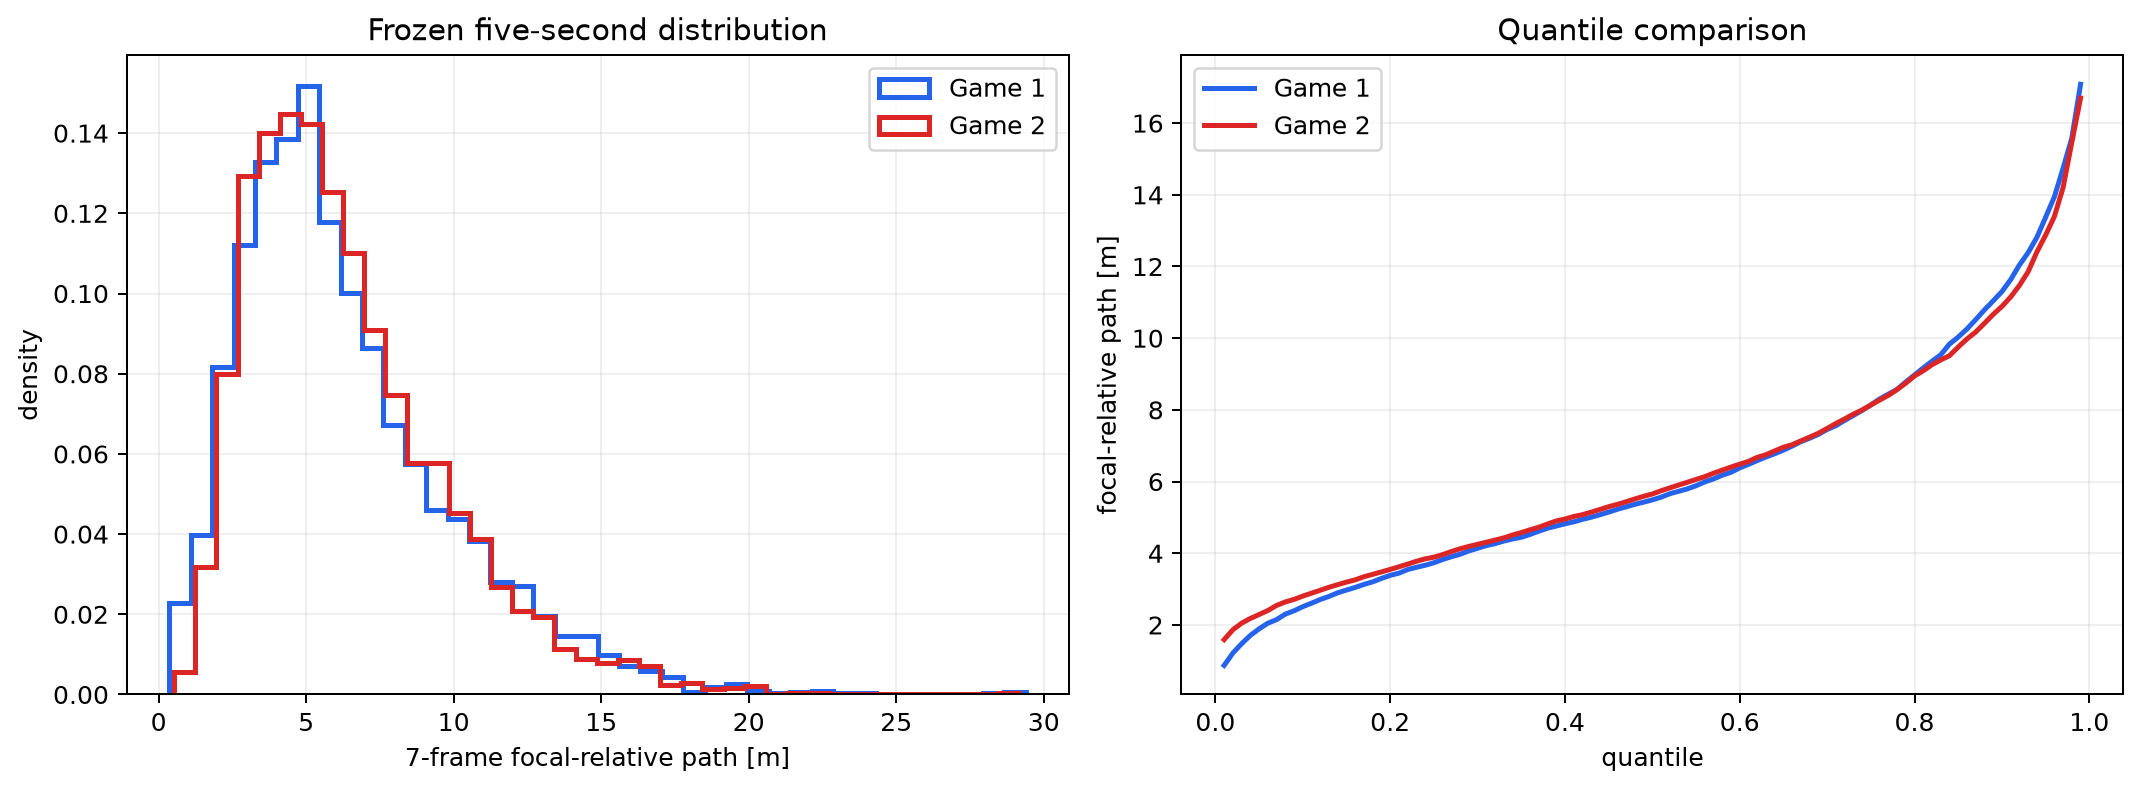

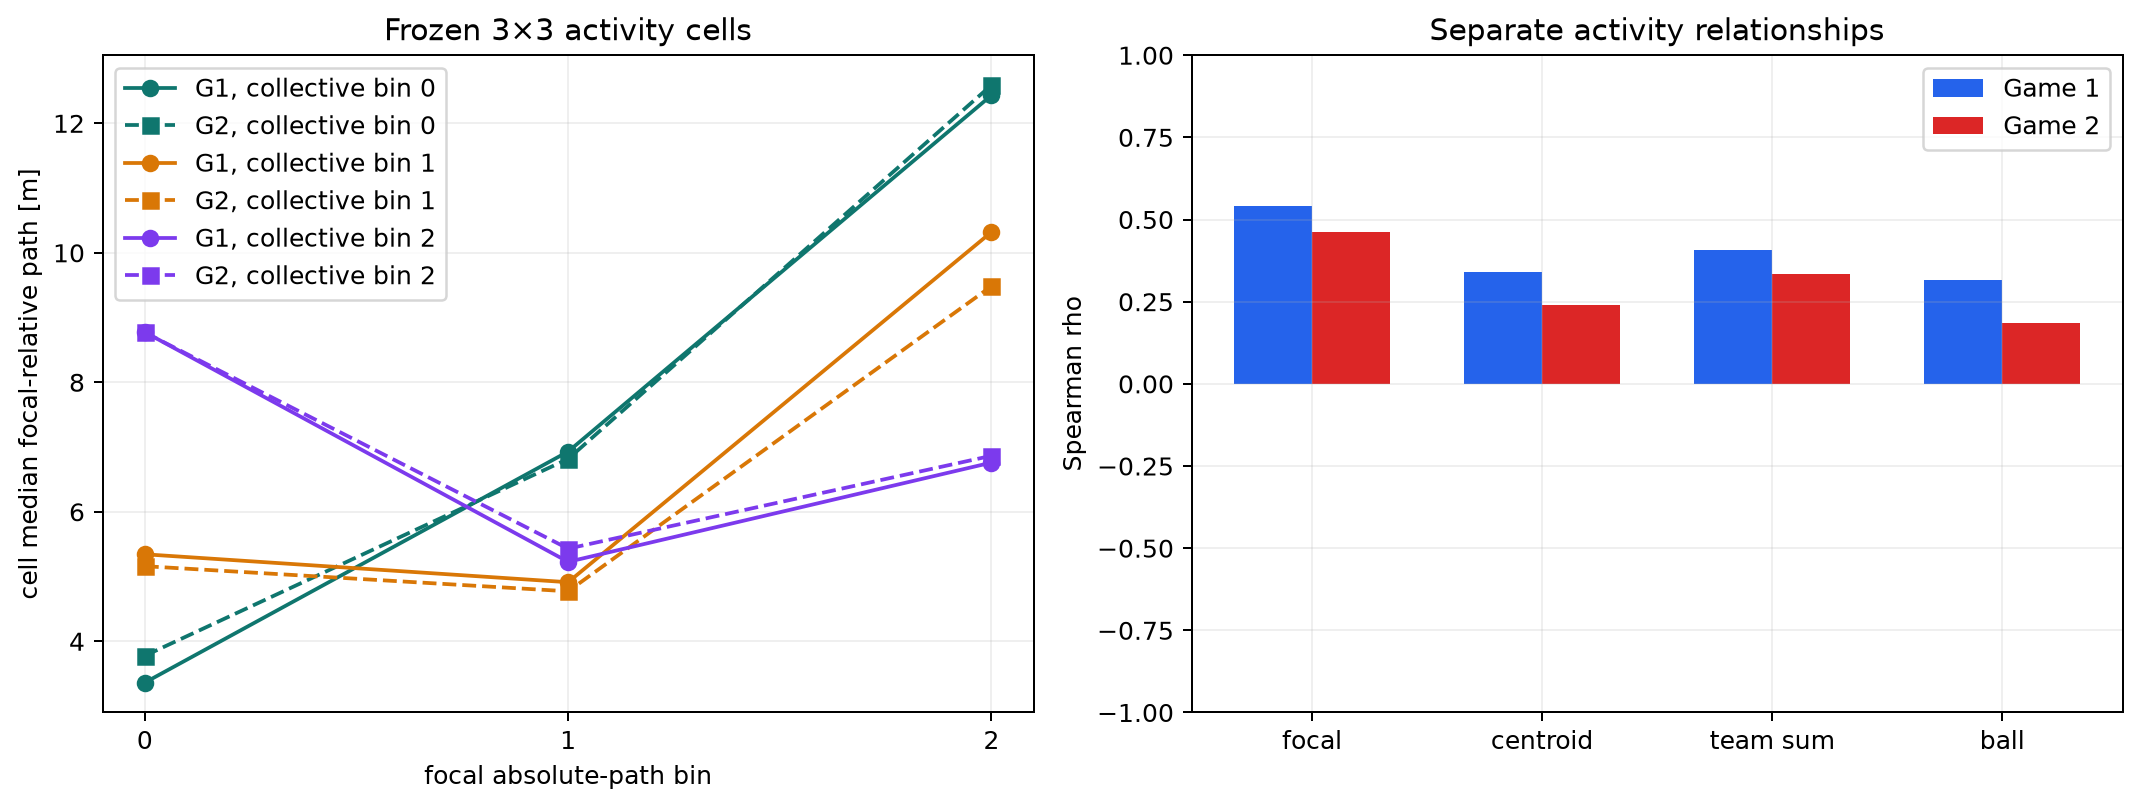

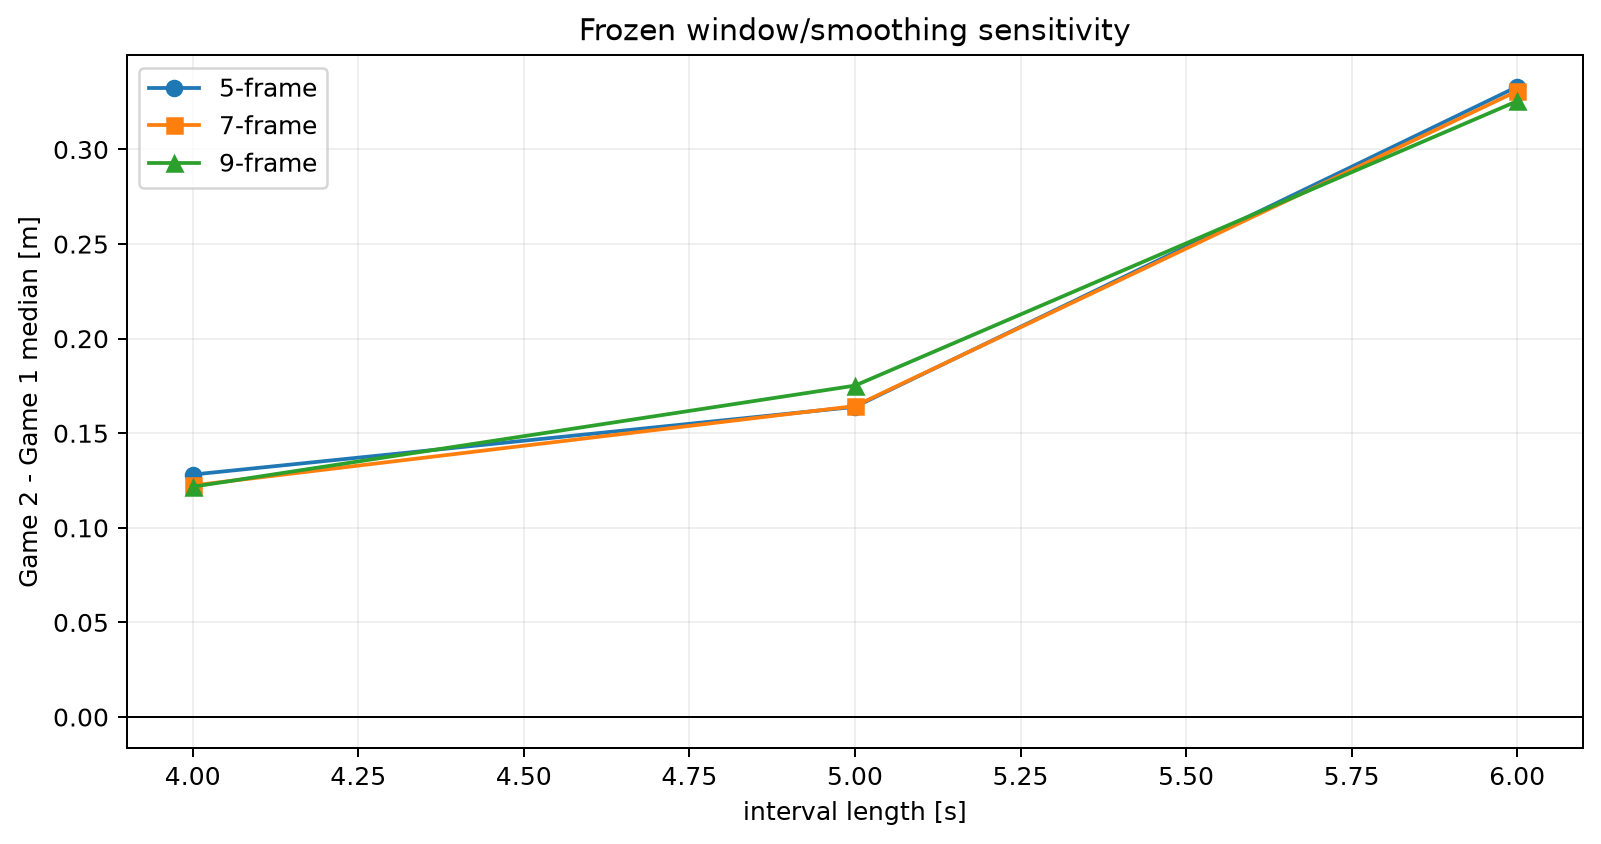

In [4]:
from IPython.display import Image, display
for name in ["phase4b_distribution_replication.png", "phase4b_activity_context.png", "phase4b_sensitivity.png"]:
    display(Image(filename=str(ROOT / "figures/phase4b" / name)))

## Claim boundary

Supported: focal-relative path is a cross-match reproducible geometric primitive with stable activity-context structure in these two sample matches.

Not supported: defensive relational reconfiguration, opponent induction, responsibility, attention, tactical interpretation, defensive quality, gravity, or off-ball value. Ordinary activity remains an explicit alternative explanation, and the frozen design does not estimate an activity-free or causal effect.